# Modeling — **SVM + TF-IDF** lintas versi dataset

**Tujuan.** Melatih & mengevaluasi SVM pada **4 versi dataset** untuk menjawab:
*apakah ukuran data & keseimbangan kelas memengaruhi performa?*

| Versi | Flag | Sifat |
|-------|------|-------|
| v1 | `in_set6k` | imbalanced, 6k |
| v2 | `in_balanced_set` | balanced, 3k |
| v3 | `in_set10k` | imbalanced, 10k |
| v4 | `in_balanced10k` | balanced, ~5.8k |

Untuk **tiap versi**: subset dari `processed_svm` → split stratified 70/20/10
(`seed=42`, urut `comment_id`) → tuning `C`/n-gram/`min_df` di val (`PredefinedSplit`)
→ refit train+val → evaluasi test. Metrik utama **macro-F1** (adil untuk kelas
timpang); accuracy dilaporkan berdampingan (hati-hati: bias ke kelas mayoritas pada
versi imbalanced).

## 0. Dependency

In [1]:
%pip install -q "pymongo[srv]" dnspython certifi python-dotenv scikit-learn matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.


## 1. Baca `processed_svm` (semua versi) dari MongoDB

In [2]:
import os, pandas as pd
from pymongo import MongoClient
import certifi
MONGO_URI=os.environ.get("MONGO_URI","")
if not MONGO_URI:
    try:
        from dotenv import load_dotenv; load_dotenv(); MONGO_URI=os.environ.get("MONGO_URI","")
    except Exception: pass
if not MONGO_URI:
    from getpass import getpass; MONGO_URI=getpass("MONGO_URI: ")
DB=os.environ.get("MONGO_DB_NAME","youtube_sentiment")
client=MongoClient(MONGO_URI,tlsCAFile=certifi.where(),serverSelectionTimeoutMS=20000)
client.admin.command("ping"); print("Koneksi MongoDB OK.")
LABELS=["Negatif","Netral","Positif"]; LABEL2ID={l:i for i,l in enumerate(LABELS)}
VERSIONS=[("v1 imbalanced 6k","in_set6k"),("v2 balanced 3k","in_balanced_set"),
          ("v3 imbalanced 10k","in_set10k"),("v4 balanced 10k","in_balanced10k")]
flags=[f for _,f in VERSIONS]
# Keanggotaan KANONIK + label dari raw_comments (punya SEMUA member, incl. yg svm-nya kosong)
proj={"_id":0,"comment_id":1,"label":1}; proj.update({f:1 for f in flags})
mem=pd.DataFrame(list(client[DB]["raw_comments"].find({"label":{"$exists":True}},proj)))
for f in flags: mem[f]=mem[f].fillna(False)
mem["label_id"]=mem["label"].map(LABEL2ID)
# Teks svm dari processed_svm (gabung; kosong -> "")
sv=pd.DataFrame(list(client[DB]["processed_svm"].find({},{"_id":0,"comment_id":1,"svm":1})))
df=mem.merge(sv,on="comment_id",how="left"); df["svm"]=df["svm"].fillna("")
print(f"{len(df)} member berlabel | per versi:", {f:int(df[f].sum()) for f in flags})
print("svm kosong (akan di-drop dari train/val):", int((df["svm"].str.len()==0).sum()))

Koneksi MongoDB OK.


10000 member berlabel | per versi: {'in_set6k': 6000, 'in_balanced_set': 3000, 'in_set10k': 10000, 'in_balanced10k': 5808}
svm kosong (akan di-drop dari train/val): 4


## 2. Fungsi: split deterministik + tuning + evaluasi

In [3]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, PredefinedSplit, train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
SEED=42; TEXT="svm"; LAB="label_id"
def build(): return Pipeline([("tfidf",TfidfVectorizer(sublinear_tf=True)),
                              ("clf",LinearSVC(class_weight="balanced",random_state=SEED))])
GRID={"tfidf__ngram_range":[(1,1),(1,2)],"tfidf__min_df":[1,2,3],"clf__C":[0.1,0.5,1.0,2.0]}

def split_version(sub):
    # Split di atas keanggotaan KANONIK (urut comment_id, stratified, seed tetap) -> identik antar model.
    sub=sub.sort_values("comment_id").reset_index(drop=True)
    tmp,te=train_test_split(sub,test_size=0.10,stratify=sub[LAB],random_state=SEED)
    tr,va=train_test_split(tmp,test_size=0.20/0.90,stratify=tmp[LAB],random_state=SEED)
    return tr,va,te

def _nonempty(d): return d[d[TEXT].str.len()>0]

def evaluate(yt,yp):
    ids=list(range(3)); rep=classification_report(yt,yp,labels=ids,target_names=LABELS,output_dict=True,zero_division=0)
    return {"accuracy":round(accuracy_score(yt,yp),4),
            "macro_f1":round(f1_score(yt,yp,average="macro",zero_division=0),4),
            "weighted_f1":round(f1_score(yt,yp,average="weighted",zero_division=0),4),
            "per_class":{l:{"f1":round(rep[l]["f1-score"],4),"support":int(rep[l]["support"])} for l in LABELS},
            "confusion_matrix":confusion_matrix(yt,yp,labels=ids).tolist()}

def run_version(flag):
    tr,va,te=split_version(df[df[flag]])
    tr,va=_nonempty(tr),_nonempty(va)            # buang teks kosong dari train/val saja
    X=pd.concat([tr[TEXT],va[TEXT]],ignore_index=True); y=pd.concat([tr[LAB],va[LAB]],ignore_index=True)
    ps=PredefinedSplit(np.r_[np.full(len(tr),-1),np.zeros(len(va))])
    gs=GridSearchCV(build(),GRID,scoring="f1_macro",cv=ps,n_jobs=-1); gs.fit(X,y)
    best=build().set_params(**gs.best_params_); best.fit(X,y)
    m=evaluate(te[LAB].tolist(),list(best.predict(te[TEXT])))  # test UTUH (kanonik, identik dgn IndoBERT)
    m.update({"n_train":len(tr),"n_test":len(te),"best_params":{k:str(v) for k,v in gs.best_params_.items()}})
    return m

## 3. Latih SVM untuk tiap versi

In [4]:
results={}
for name,flag in VERSIONS:
    m=run_version(flag); results[name]=m
    print(f"[{name:<18}] n_train={m['n_train']:<5} macro-F1={m['macro_f1']:.3f} acc={m['accuracy']:.3f} | "
          + " ".join(f"{l[:3]}={m['per_class'][l]['f1']:.2f}" for l in LABELS))

[v1 imbalanced 6k  ] n_train=4198  macro-F1=0.602 acc=0.643 | Neg=0.70 Net=0.45 Pos=0.65


[v2 balanced 3k    ] n_train=2098  macro-F1=0.694 acc=0.693 | Neg=0.76 Net=0.66 Pos=0.66


[v3 imbalanced 10k ] n_train=6997  macro-F1=0.626 acc=0.656 | Neg=0.71 Net=0.49 Pos=0.68


[v4 balanced 10k   ] n_train=4063  macro-F1=0.651 acc=0.651 | Neg=0.66 Net=0.67 Pos=0.62


## 4. Tabel perbandingan

In [5]:
rows=[]
for name,_ in VERSIONS:
    m=results[name]
    rows.append({"versi":name,"n_train":m["n_train"],"n_test":m["n_test"],
                 "macro_F1":m["macro_f1"],"accuracy":m["accuracy"],"weighted_F1":m["weighted_f1"],
                 **{f"F1_{l}":m["per_class"][l]["f1"] for l in LABELS}})
import pandas as pd
comp=pd.DataFrame(rows); comp

,versi,n_train,n_test,macro_F1,accuracy,weighted_F1,F1_Negatif,F1_Netral,F1_Positif
0,v1 imbalanced 6k,4198,600,0.6015,0.6433,0.6408,0.7016,0.4479,0.6549
1,v2 balanced 3k,2098,300,0.6944,0.6933,0.6944,0.7629,0.6571,0.6633
2,v3 imbalanced 10k,6997,1000,0.6256,0.6560,0.6550,0.7077,0.4855,0.6835
3,v4 balanced 10k,4063,581,0.6511,0.6506,0.6511,0.6649,0.6684,0.6200


## 5. Grafik perbandingan (macro-F1 & F1 per kelas)

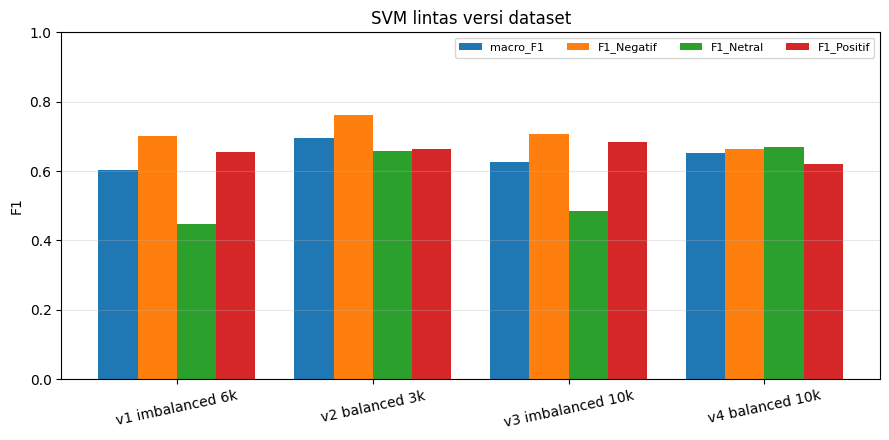

In [6]:
import matplotlib.pyplot as plt, numpy as np
names=[n for n,_ in VERSIONS]
metrics=["macro_F1"]+[f"F1_{l}" for l in LABELS]
x=np.arange(len(names)); w=0.2
fig,ax=plt.subplots(figsize=(9,4.5))
for k,met in enumerate(metrics):
    ax.bar(x+k*w,[comp.loc[comp.versi==n,met].values[0] for n in names],w,label=met)
ax.set_xticks(x+w*1.5,names,rotation=12); ax.set_ylim(0,1); ax.set_ylabel("F1")
ax.legend(ncol=4,fontsize=8); ax.set_title("SVM lintas versi dataset"); ax.grid(axis="y",alpha=.3)
fig.tight_layout(); plt.show()

## 6. Confusion matrix tiap versi

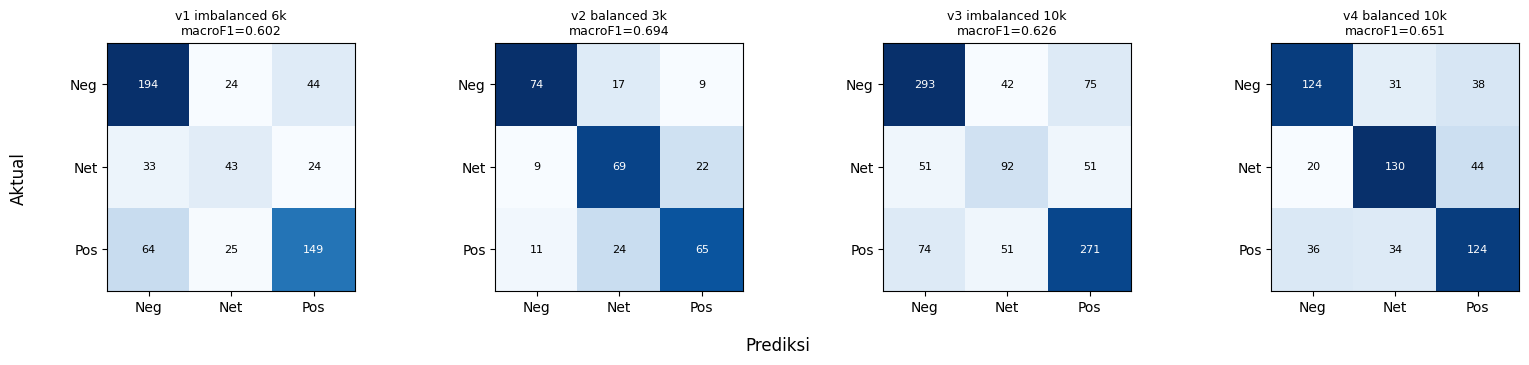

In [7]:
fig2,axes=plt.subplots(1,4,figsize=(16,3.6))
for ax,(name,_) in zip(axes,VERSIONS):
    cm=np.array(results[name]["confusion_matrix"]); im=ax.imshow(cm,cmap="Blues")
    ax.set_xticks(range(3),[l[:3] for l in LABELS]); ax.set_yticks(range(3),[l[:3] for l in LABELS])
    ax.set_title(f"{name}\nmacroF1={results[name]['macro_f1']:.3f}",fontsize=9)
    th=cm.max()/2
    for i in range(3):
        for j in range(3): ax.text(j,i,cm[i,j],ha="center",va="center",fontsize=8,color="white" if cm[i,j]>th else "black")
fig2.supxlabel("Prediksi"); fig2.supylabel("Aktual"); fig2.tight_layout(); plt.show()

## 7. Simpan metrik

In [8]:
import json,pathlib
ROOT=pathlib.Path.cwd()
for _p in [ROOT,*ROOT.parents]:
    if (_p/"configs").exists() or (_p/".git").exists(): ROOT=_p; break
REP=ROOT/"outputs"/"reports"; REP.mkdir(parents=True,exist_ok=True)
json.dump({"model":"SVM+TF-IDF","by_version":results},open(REP/"svm_versions_metrics.json","w"),ensure_ascii=False,indent=2)
fig.savefig(REP/"svm_versions_compare.png",dpi=120); fig2.savefig(REP/"svm_versions_confusion.png",dpi=120)
comp.to_csv(REP/"svm_versions_table.csv",index=False)
print("Tersimpan ke",REP)

Tersimpan ke /home/ravi/Projects/jokowi_sentiment_project/outputs/reports


## Interpretasi

Bandingkan baris tabel: **balance vs imbalance** (v1↔v2, v3↔v4) dan **ukuran data**
(v1↔v3, v2↔v4). Macro-F1 = metrik adil; accuracy pada versi imbalanced (v1/v3) cenderung
lebih tinggi karena terbantu kelas mayoritas — **bukan** indikasi model lebih baik
mengenali semua kelas. Pembanding IndoBERT per versi: `indobert_finetune_colab.ipynb`
(set `VERSION`).

## 8. Perbandingan final: SVM vs IndoBERT (lintas versi)

Memuat metrik IndoBERT per versi (`indobert_metrics_{is6,ibs,is10,ib10}.json` —
dihasilkan `indobert_finetune_colab.ipynb` dengan `VERSION_FLAG` berbeda) dan
membandingkannya dengan SVM pada **test set identik** tiap versi.

            versi    SVM  IndoBERT   winner
 v1 imbalanced 6k 0.6015    0.5973      SVM
   v2 balanced 3k 0.6944    0.6330      SVM
v3 imbalanced 10k 0.6256    0.6442 IndoBERT
  v4 balanced 10k 0.6511    0.6660 IndoBERT


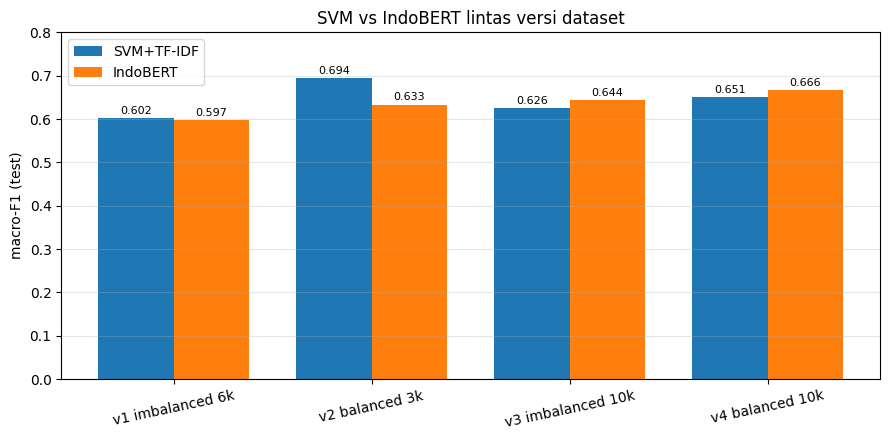


Tersimpan: model_comparison.csv + svm_vs_indobert.png


In [9]:
import json, numpy as np, matplotlib.pyplot as plt
SUF={"v1 imbalanced 6k":"is6","v2 balanced 3k":"ibs","v3 imbalanced 10k":"is10","v4 balanced 10k":"ib10"}
rows=[]
for name,_ in VERSIONS:
    s=results[name]; f=REP/f"indobert_metrics_{SUF[name]}.json"
    b=json.load(open(f))["test"] if f.exists() else None
    rows.append({"versi":name,"SVM":s["macro_f1"],"IndoBERT":round(b["macro_f1"],4) if b else None,
                 "winner":("-" if not b else ("SVM" if s["macro_f1"]>b["macro_f1"] else "IndoBERT"))})
cmp=pd.DataFrame(rows); print(cmp.to_string(index=False))
have=[r for r in rows if r["IndoBERT"] is not None]
if have:
    names=[r["versi"] for r in have]; x=np.arange(len(names)); w=0.38
    fig3,ax=plt.subplots(figsize=(9,4.5))
    ax.bar(x-w/2,[r["SVM"] for r in have],w,label="SVM+TF-IDF")
    ax.bar(x+w/2,[r["IndoBERT"] for r in have],w,label="IndoBERT")
    ax.set_xticks(x,names,rotation=12); ax.set_ylim(0,0.8); ax.set_ylabel("macro-F1 (test)")
    ax.legend(); ax.set_title("SVM vs IndoBERT lintas versi dataset"); ax.grid(axis="y",alpha=.3)
    for i,r in enumerate(have):
        ax.text(i-w/2,r["SVM"]+.01,f"{r['SVM']:.3f}",ha="center",fontsize=8)
        ax.text(i+w/2,r["IndoBERT"]+.01,f"{r['IndoBERT']:.3f}",ha="center",fontsize=8)
    fig3.tight_layout(); plt.show()
    cmp.to_csv(REP/"model_comparison.csv",index=False); fig3.savefig(REP/"svm_vs_indobert.png",dpi=120)
    print("\nTersimpan: model_comparison.csv + svm_vs_indobert.png")

**Temuan utama — *crossover* ukuran data:** pada data kecil (v1 6k, v2 3k) **SVM
unggul** (paling tajam di v2: 0,694 vs 0,633); begitu data membesar ke 10k (v3, v4)
**IndoBERT menyalip** (0,644 vs 0,626; 0,666 vs 0,651). Khas: transformer butuh lebih
banyak data untuk mengungguli ML klasik, terutama pada kelas sulit (Netral) di mana
pemahaman konteks membantu.